# Sistem Klasifikasi Otomatis Anomali Sel Darah

In [19]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

In [20]:
# kagglehub.login()

In [21]:
file_path = "blood_cell_anomaly_detection.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "alitaqishah/blood-cell-anomaly-detection-2025",
  file_path,
)

/tmp/ipykernel_2939/603024074.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'blood-cell-anomaly-detection-2025' dataset.


# Data Understanding

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   cell_id                                  5880 non-null   object 
 1   cell_type                                5880 non-null   object 
 2   anomaly_label                            5880 non-null   int64  
 3   disease_category                         5880 non-null   object 
 4   cell_diameter_um                         5880 non-null   float64
 5   nucleus_area_pct                         5880 non-null   float64
 6   chromatin_density                        5880 non-null   float64
 7   cytoplasm_ratio                          5880 non-null   float64
 8   circularity                              5880 non-null   float64
 9   eccentricity                             5880 non-null   float64
 10  granularity_score                        5880 no

In [23]:
df.describe()

,anomaly_label,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,...,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,...,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.319728,10.176267,43.537976,0.391394,0.564173,0.769263,0.365458,1.882109,1.769252,0.842866,...,13.547194,41.021956,249792.623469,88.942211,33.495867,76.006803,336.235374,0.317583,0.853243,0.866370
std,0.466411,3.642051,33.419390,0.310006,0.335282,0.158219,0.201501,1.428336,1.229362,0.096033,...,2.025136,5.484636,79472.676228,9.927005,1.480168,25.032178,111.922015,0.349655,0.106589,0.094065
min,0.000000,1.000000,0.000000,0.000000,0.050000,0.100000,0.000000,0.000000,1.000000,0.290000,...,5.400000,20.300000,20000.000000,60.000000,28.000000,40.000000,224.000000,0.000000,0.417300,0.471700
25%,0.000000,7.630000,0.000000,0.000000,0.276000,0.711000,0.214750,0.670000,1.000000,0.784000,...,12.200000,37.300000,194653.250000,82.300000,32.500000,60.000000,224.000000,0.063675,0.799000,0.817250
50%,0.000000,10.055000,54.500000,0.479500,0.452000,0.805000,0.331000,1.320000,1.000000,0.854000,...,13.500000,41.000000,250070.500000,88.900000,33.500000,100.000000,256.000000,0.113150,0.877450,0.883400
75%,1.000000,12.860000,72.300000,0.635000,1.000000,0.879000,0.456000,2.980000,2.300000,0.918000,...,14.900000,44.800000,303863.500000,95.700000,34.500000,100.000000,360.000000,0.743850,0.929350,0.934000
max,1.000000,21.180000,99.000000,1.000000,1.000000,1.000000,0.990000,6.000000,7.200000,1.000000,...,20.000000,60.000000,543084.000000,120.000000,38.000000,100.000000,512.000000,1.000000,1.000000,1.000000


In [24]:
df.describe(include=['object'])

,cell_id,cell_type,disease_category,patient_age_group,patient_sex,dataset_source,staining_protocol,microscope_model
count,5880,5880,5880,5880,5880,5880,5880,5880
unique,5880,19,8,3,2,3,3,3
top,CELL_000861,Neutrophil,Normal_WBC,Adult,F,PBC_Dataset,Giemsa,Olympus_BX51
freq,1,1100,2800,3276,2966,2351,2627,2398


In [25]:
df.head()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


# Data Preprocessing

In [26]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [27]:
df_clean = df.drop(columns=['cell_id','cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score'])

In [28]:
if df_clean.isnull().sum().sum() > 0:
    for col in df_clean.columns:
        if df_clean[col].dtype == 'object':
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    print("Missing values telah ditangani.")
else:
    print("Tidak ada missing values dalam dataset.")

Tidak ada missing values dalam dataset.


In [29]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'cell_type' in numeric_cols:
    numeric_cols.remove('cell_type')


for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)
print("Outlier telah ditangani menggunakan metode IQR Capping.")

Outlier telah ditangani menggunakan metode IQR Capping.


In [30]:
X = df_clean.drop(columns=['cell_type'])
y = df_clean['cell_type']

In [31]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
le_feature = LabelEncoder()
for col in categorical_cols:
    X[col] = le_feature.fit_transform(X[col])

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
y_encoded = pd.Series(y_encoded, name='cell_type')
y_encoded.unique()

array([ 5,  8,  9, 12,  7,  6, 15, 10,  2,  1,  4, 18, 13, 11, 17, 16,  3,
       14,  0])

In [33]:
df_final = pd.DataFrame(X_scaled, columns=X.columns)
df_final['cell_type'] = y_encoded

print("Standarisasi data selesai.")
print("\n--- 5 Data Pertama Setelah Preprocessing ---")
display(df_final.head())

Standarisasi data selesai.

--- 5 Data Pertama Setelah Preprocessing ---


,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,...,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cell_type
0,1.458650,-1.132890,1.374107,0.456721,0.485858,-0.784998,-1.549991,0.875119,1.559913,2.309342,...,0.436159,0.096522,-0.347712,-1.424801,-1.448056,-1.019596,1.454491,0.958576,-1.002885,5
1,1.458650,-1.132890,1.728356,0.899615,0.618125,-0.594097,0.595896,0.425722,0.432632,2.309342,...,0.216074,0.663111,0.359328,1.021003,-0.143941,1.226227,1.454491,0.958576,-1.002885,5
2,-0.685565,0.746205,0.888044,0.357967,0.182612,-0.561286,0.030426,0.237603,0.789721,1.350078,...,-0.334139,-0.249142,-1.276965,-0.337777,-1.448056,1.226227,-1.170557,0.958576,1.570554,8
3,-0.685565,0.276432,-0.773358,-1.302887,-1.262647,1.299991,0.748138,-1.016527,-1.016730,-0.659809,...,2.398585,-1.502150,0.339127,-0.677472,-1.448056,1.226227,-1.170557,0.958576,1.570554,9
4,-0.685565,0.276432,-0.726674,-1.302887,-1.262647,1.299991,1.618093,-1.063556,-0.960716,-0.659809,...,-0.792650,-0.266106,-0.509321,-0.066021,-1.448056,1.226227,0.141967,0.958576,-1.002885,9


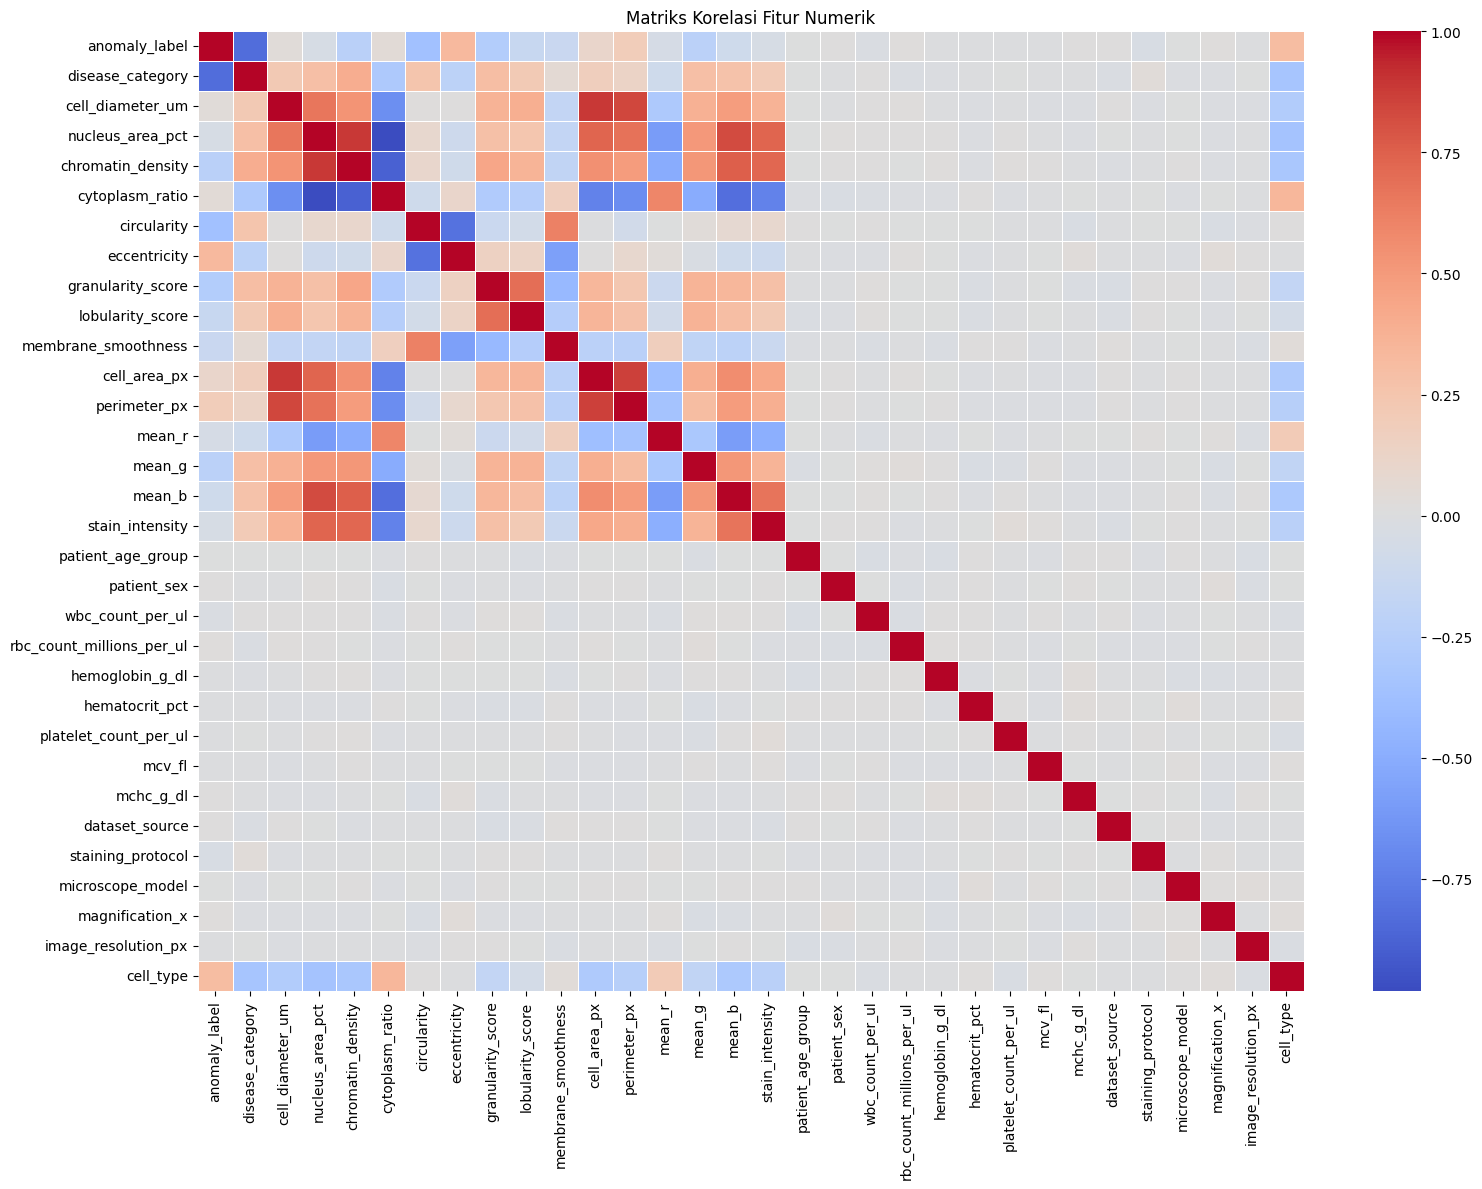

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_df = df_final.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(16, 12))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik')
plt.tight_layout()
plt.savefig('eda_korelasi.png')
# plt.show()

In [34]:
target_corr = correlation_matrix['cell_type'].abs().sort_values(ascending=True)

low_corr_features = target_corr[target_corr < 0.1].index.tolist()

print("Fitur yang disarankan untuk di-drop (Korelasi Rendah):")
print(low_corr_features)

df_final_cleaned = df_final.drop(columns=low_corr_features)

Fitur yang disarankan untuk di-drop (Korelasi Rendah):
['eccentricity', 'rbc_count_millions_per_ul', 'dataset_source', 'patient_sex', 'staining_protocol', 'hemoglobin_g_dl', 'patient_age_group', 'mchc_g_dl', 'circularity', 'microscope_model', 'image_resolution_px', 'wbc_count_per_ul', 'mcv_fl', 'hematocrit_pct', 'platelet_count_per_ul', 'magnification_x', 'membrane_smoothness', 'lobularity_score']


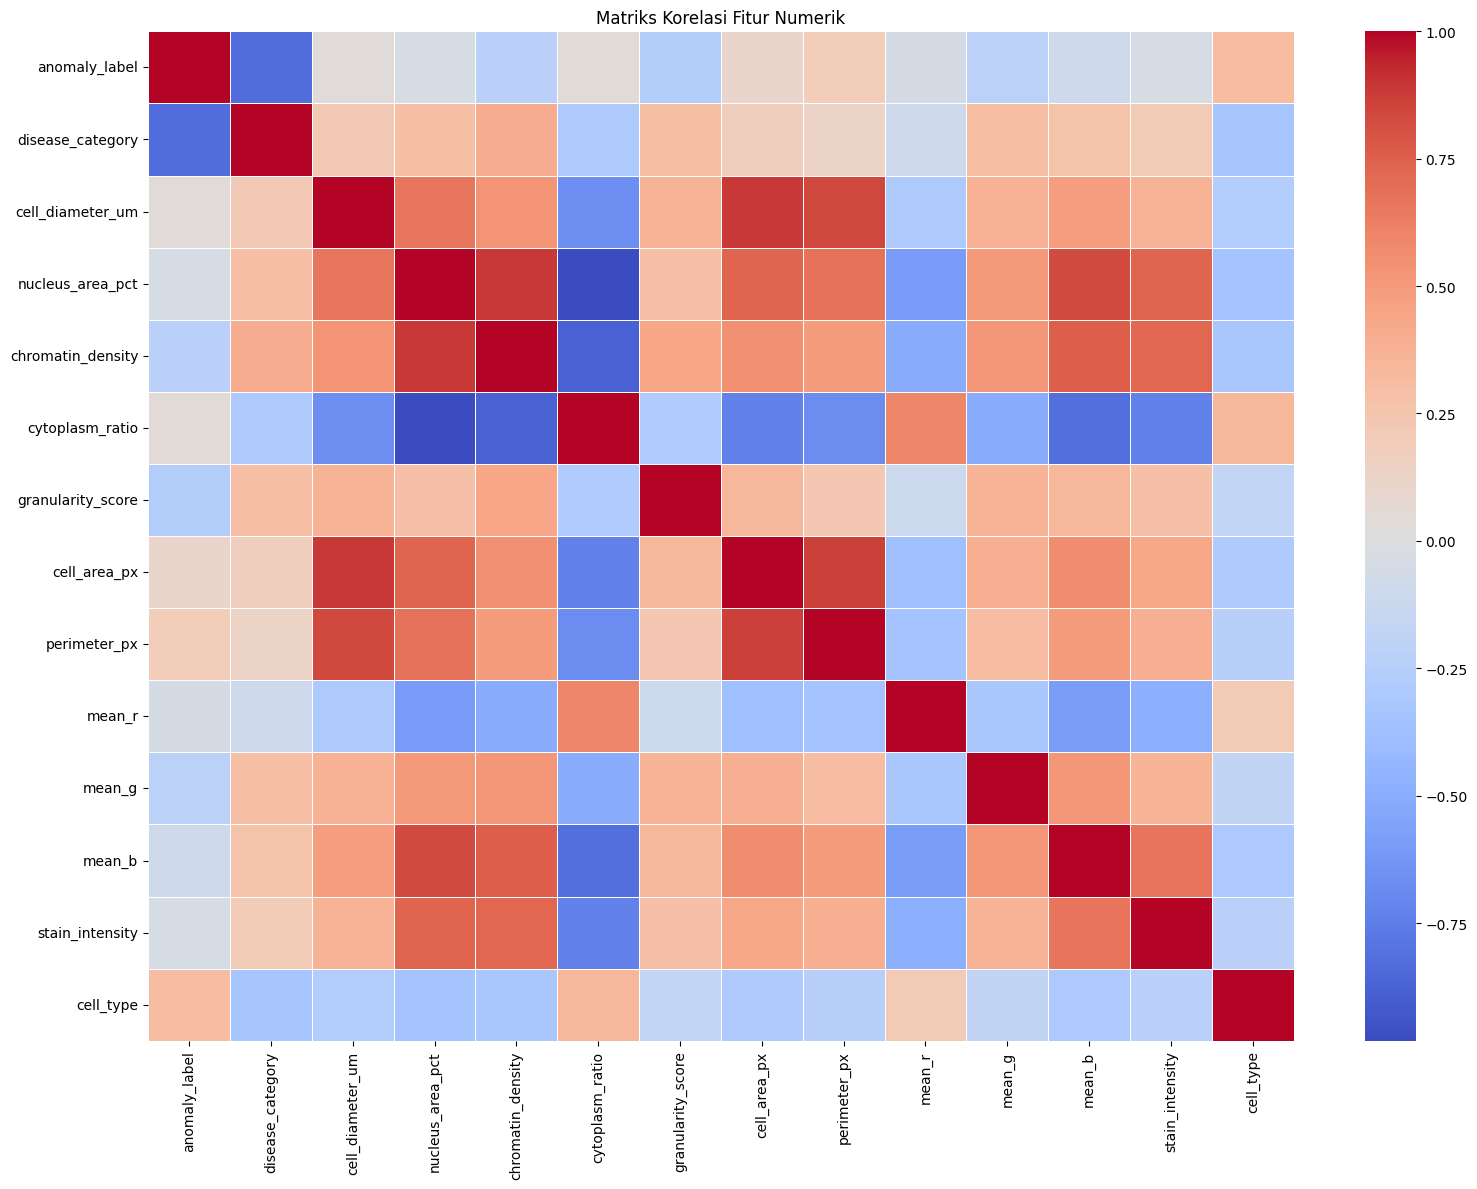

In [35]:
numeric_df = df_final_cleaned.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(16, 12))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik')
plt.tight_layout()
plt.savefig('eda_korelasi.png')

In [36]:
X_scaled = df_final_cleaned.drop(columns=['cell_type'])
y_encoded = df_final_cleaned['cell_type']

# Exploratory Data Analysis (EDA)

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
sns.set(style="whitegrid")

/tmp/ipykernel_2939/2443809496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, y='cell_type', order=order, palette='viridis')


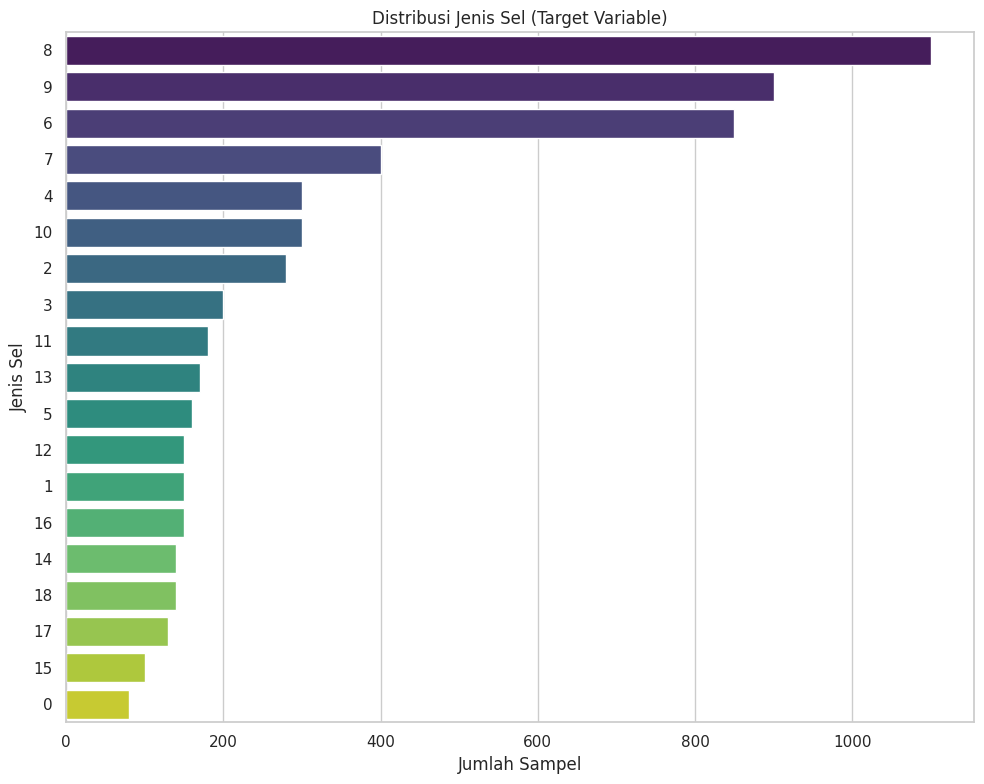

In [39]:
plt.figure(figsize=(10, 8))
order = df_final['cell_type'].value_counts().index
sns.countplot(data=df_final, y='cell_type', order=order, palette='viridis')
plt.title('Distribusi Jenis Sel (Target Variable)')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Jenis Sel')
plt.tight_layout()
plt.savefig('eda_distribusi_target.png')
# plt.show()

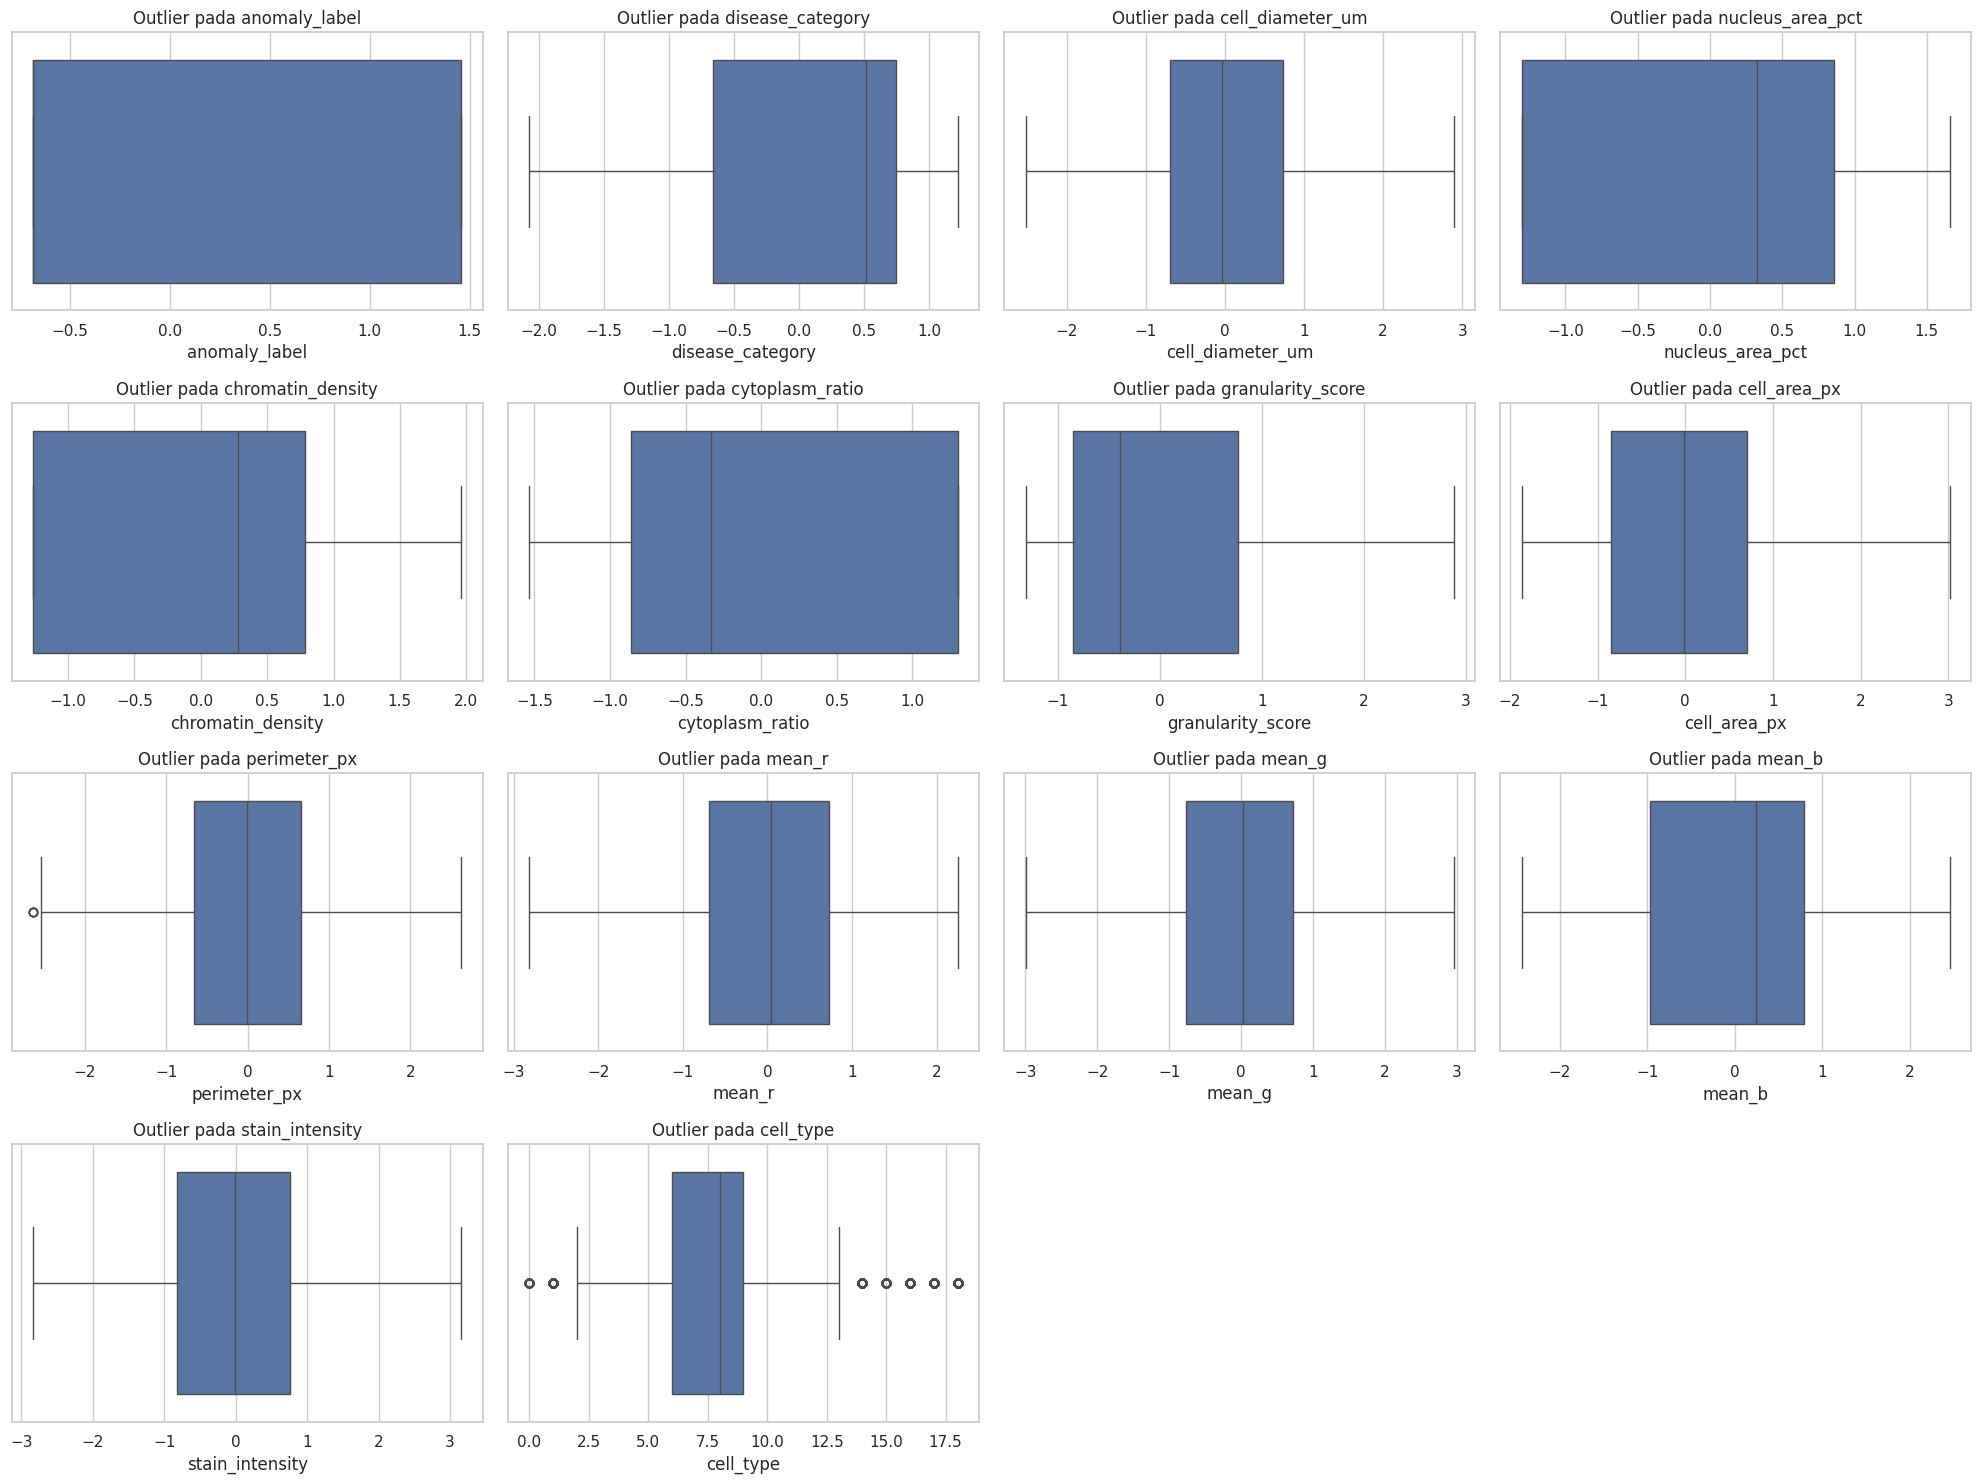

In [40]:
plt.figure(figsize=(20, 15))
for i, feature in enumerate(df_final_cleaned):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=df_final_cleaned[feature])
    plt.title(f'Outlier pada {feature}')

plt.tight_layout()
plt.show()

# Data Splitting

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
variations = [
    {'test_size': 0.3, 'label': '70:30'},
    {'test_size': 0.2, 'label': '80:20'},
    {'test_size': 0.1, 'label': '90:10'}
]

print("--- Hasil Pembagian Data (Data Splitting) ---")

for var in variations:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=var['test_size'],
        random_state=42,
        stratify=y
    )

    print(f"\nVariasi {var['label']}:")
    print(f"  - Jumlah Data Training: {X_train.shape[0]} sampel")
    print(f"  - Jumlah Data Testing : {X_test.shape[0]} sampel")
    print(f"  - Total Fitur         : {X_train.shape[1]}")

--- Hasil Pembagian Data (Data Splitting) ---

Variasi 70:30:
  - Jumlah Data Training: 4116 sampel
  - Jumlah Data Testing : 1764 sampel
  - Total Fitur         : 31

Variasi 80:20:
  - Jumlah Data Training: 4704 sampel
  - Jumlah Data Testing : 1176 sampel
  - Total Fitur         : 31

Variasi 90:10:
  - Jumlah Data Training: 5292 sampel
  - Jumlah Data Testing : 588 sampel
  - Total Fitur         : 31


70:10

In [43]:
X_train70, X_test30, y_train70, y_test30 = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

80:20

In [44]:
X_train80, X_test20, y_train80, y_test20 = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

90:10

In [45]:
X_train90, X_test10, y_train90, y_test10 = train_test_split(
    X_scaled, y_encoded, test_size=0.1, random_state=42, stratify=y_encoded
)

# Model Building

## Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

70:30

In [47]:
rf_70 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_70.fit(X_train70, y_train70)

y_pred70 = rf_70.predict(X_test30)
print("=== CLASSIFICATION REPORT: RANDOM FOREST (70:30) ===")
print(classification_report(y_test30, y_pred70, target_names=le_target.classes_))

=== CLASSIFICATION REPORT: RANDOM FOREST (70:30) ===
                           precision    recall  f1-score   support

                 Artefact       1.00      1.00      1.00        24
                 Basophil       0.98      0.96      0.97        45
               Blast_Cell       0.80      0.88      0.84        84
              Elliptocyte       0.81      0.85      0.83        60
               Eosinophil       0.98      0.91      0.94        90
Hypersegmented_Neutrophil       0.96      0.92      0.94        48
               Lymphocyte       1.00      1.00      1.00       255
                 Monocyte       0.99      0.99      0.99       120
               Neutrophil       0.97      0.99      0.98       330
               Normal_RBC       1.00      1.00      1.00       270
                 Platelet       1.00      1.00      1.00        90
            Prolymphocyte       0.78      0.65      0.71        54
      Reactive_Lymphocyte       0.94      0.98      0.96        45
        

80:20

In [48]:
rf_80 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_80.fit(X_train80, y_train80)

y_pred80 = rf_80.predict(X_test20)
print("=== CLASSIFICATION REPORT: RANDOM FOREST (80:20) ===")
print(classification_report(y_test20, y_pred80, target_names=le_target.classes_))

=== CLASSIFICATION REPORT: RANDOM FOREST (80:20) ===
                           precision    recall  f1-score   support

                 Artefact       1.00      1.00      1.00        16
                 Basophil       1.00      1.00      1.00        30
               Blast_Cell       0.80      0.93      0.86        56
              Elliptocyte       0.80      0.82      0.81        40
               Eosinophil       0.96      0.92      0.94        60
Hypersegmented_Neutrophil       0.97      0.88      0.92        32
               Lymphocyte       1.00      1.00      1.00       170
                 Monocyte       1.00      1.00      1.00        80
               Neutrophil       0.98      0.99      0.98       220
               Normal_RBC       1.00      1.00      1.00       180
                 Platelet       1.00      1.00      1.00        60
            Prolymphocyte       0.85      0.64      0.73        36
      Reactive_Lymphocyte       0.91      0.97      0.94        30
        

90:10

In [49]:
rf_90 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_90.fit(X_train90, y_train90)

y_pred90 = rf_90.predict(X_test10)
print("=== CLASSIFICATION REPORT: RANDOM FOREST (90:10) ===")
print(classification_report(y_test10, y_pred90, target_names=le_target.classes_))

=== CLASSIFICATION REPORT: RANDOM FOREST (90:10) ===
                           precision    recall  f1-score   support

                 Artefact       1.00      1.00      1.00         8
                 Basophil       0.94      1.00      0.97        15
               Blast_Cell       0.79      0.93      0.85        28
              Elliptocyte       0.68      0.75      0.71        20
               Eosinophil       1.00      0.97      0.98        30
Hypersegmented_Neutrophil       1.00      0.94      0.97        16
               Lymphocyte       1.00      1.00      1.00        85
                 Monocyte       1.00      1.00      1.00        40
               Neutrophil       0.99      0.99      0.99       110
               Normal_RBC       1.00      1.00      1.00        90
                 Platelet       1.00      1.00      1.00        30
            Prolymphocyte       0.85      0.61      0.71        18
      Reactive_Lymphocyte       1.00      1.00      1.00        15
        

In [50]:
from sklearn.metrics import accuracy_score
train_acc_rf = accuracy_score(y_train80, rf_80.predict(X_train80))
test_acc_rf = accuracy_score(y_test20, rf_80.predict(X_test20))

print("=== CHECK OVERFITTING: RANDOM FOREST (80:20) ===")
print(f"Accuracy Training : {train_acc_rf:.4f}")
print(f"Accuracy Testing  : {test_acc_rf:.4f}")
print(f"Gap (Selisih)     : {abs(train_acc_rf - test_acc_rf):.4f}")

=== CHECK OVERFITTING: RANDOM FOREST (80:20) ===
Accuracy Training : 1.0000
Accuracy Testing  : 0.9626
Gap (Selisih)     : 0.0374


# Xgboost

In [51]:
from xgboost import XGBClassifier

70:30

In [52]:
xgb_70 = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_70.fit(X_train70, y_train70)

y_pred_xgb70 = xgb_70.predict(X_test30)
print("=== CLASSIFICATION REPORT: XGBOOST (70:30) ===")
print(classification_report(y_test30, y_pred_xgb70, target_names=le_target.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:57:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== CLASSIFICATION REPORT: XGBOOST (70:30) ===
                           precision    recall  f1-score   support

                 Artefact       1.00      1.00      1.00        24
                 Basophil       0.96      0.96      0.96        45
               Blast_Cell       0.83      0.86      0.84        84
              Elliptocyte       0.81      0.73      0.77        60
               Eosinophil       0.98      0.92      0.95        90
Hypersegmented_Neutrophil       0.98      0.85      0.91        48
               Lymphocyte       1.00      1.00      1.00       255
                 Monocyte       1.00      0.98      0.99       120
               Neutrophil       0.98      0.99      0.98       330
               Normal_RBC       1.00      1.00      1.00       270
                 Platelet       1.00      1.00      1.00        90
            Prolymphocyte       0.75      0.72      0.74        54
      Reactive_Lymphocyte       0.90      0.98      0.94        45
              

80:20

In [53]:
xgb_80 = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_80.fit(X_train80, y_train80)

y_pred_xgb80 = xgb_80.predict(X_test20)
print("=== CLASSIFICATION REPORT: XGBOOST (80:20) ===")
print(classification_report(y_test20, y_pred_xgb80, target_names=le_target.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:57:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== CLASSIFICATION REPORT: XGBOOST (80:20) ===
                           precision    recall  f1-score   support

                 Artefact       1.00      1.00      1.00        16
                 Basophil       0.97      1.00      0.98        30
               Blast_Cell       0.82      0.82      0.82        56
              Elliptocyte       0.82      0.82      0.82        40
               Eosinophil       0.98      0.92      0.95        60
Hypersegmented_Neutrophil       0.90      0.88      0.89        32
               Lymphocyte       1.00      1.00      1.00       170
                 Monocyte       1.00      0.99      0.99        80
               Neutrophil       0.97      0.99      0.98       220
               Normal_RBC       1.00      1.00      1.00       180
                 Platelet       1.00      1.00      1.00        60
            Prolymphocyte       0.72      0.72      0.72        36
      Reactive_Lymphocyte       0.90      0.93      0.92        30
              

90:10

In [54]:
xgb_90 = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_90.fit(X_train90, y_train90)

y_pred_xgb90 = xgb_90.predict(X_test10)
print("=== CLASSIFICATION REPORT: XGBOOST (90:10) ===")
print(classification_report(y_test10, y_pred_xgb90, target_names=le_target.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:57:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== CLASSIFICATION REPORT: XGBOOST (90:10) ===
                           precision    recall  f1-score   support

                 Artefact       1.00      1.00      1.00         8
                 Basophil       1.00      1.00      1.00        15
               Blast_Cell       0.82      0.82      0.82        28
              Elliptocyte       0.81      0.85      0.83        20
               Eosinophil       0.97      0.97      0.97        30
Hypersegmented_Neutrophil       1.00      0.88      0.93        16
               Lymphocyte       1.00      1.00      1.00        85
                 Monocyte       1.00      1.00      1.00        40
               Neutrophil       0.99      0.99      0.99       110
               Normal_RBC       1.00      1.00      1.00        90
                 Platelet       1.00      1.00      1.00        30
            Prolymphocyte       0.72      0.72      0.72        18
      Reactive_Lymphocyte       0.94      1.00      0.97        15
              

In [55]:
train_acc_xgb = accuracy_score(y_train80, xgb_80.predict(X_train80))
test_acc_xgb = accuracy_score(y_test20, xgb_80.predict(X_test20))

print("=== CHECK OVERFITTING: XGBOOST (80:20) ===")
print(f"Accuracy Training : {train_acc_xgb:.4f}")
print(f"Accuracy Testing  : {test_acc_xgb:.4f}")
print(f"Gap (Selisih)     : {abs(train_acc_xgb - test_acc_xgb):.4f}")

=== CHECK OVERFITTING: XGBOOST (80:20) ===
Accuracy Training : 1.0000
Accuracy Testing  : 0.9575
Gap (Selisih)     : 0.0425


# SVM

In [56]:
from sklearn.svm import SVC

70:30

In [57]:
svm_70 = SVC(kernel='rbf', probability=True, random_state=42)
svm_70.fit(X_train70, y_train70)

y_pred_svm70 = svm_70.predict(X_test30)
print("=== CLASSIFICATION REPORT: SVM (70:30) ===")
print(classification_report(y_test30, y_pred_svm70, target_names=le_target.classes_))

=== CLASSIFICATION REPORT: SVM (70:30) ===
                           precision    recall  f1-score   support

                 Artefact       1.00      1.00      1.00        24
                 Basophil       0.96      0.96      0.96        45
               Blast_Cell       0.83      0.88      0.86        84
              Elliptocyte       0.78      0.85      0.82        60
               Eosinophil       0.99      0.94      0.97        90
Hypersegmented_Neutrophil       0.96      0.94      0.95        48
               Lymphocyte       1.00      1.00      1.00       255
                 Monocyte       1.00      0.99      1.00       120
               Neutrophil       0.98      1.00      0.99       330
               Normal_RBC       1.00      1.00      1.00       270
                 Platelet       1.00      1.00      1.00        90
            Prolymphocyte       0.80      0.72      0.76        54
      Reactive_Lymphocyte       0.96      0.98      0.97        45
              Schi

80:20

In [58]:
svm_80 = SVC(kernel='rbf', probability=True, random_state=42)
svm_80.fit(X_train80, y_train80)

y_pred_svm80 = svm_80.predict(X_test20)
print("=== CLASSIFICATION REPORT: SVM (80:20) ===")
print(classification_report(y_test20, y_pred_svm80, target_names=le_target.classes_))

=== CLASSIFICATION REPORT: SVM (80:20) ===
                           precision    recall  f1-score   support

                 Artefact       1.00      1.00      1.00        16
                 Basophil       0.97      1.00      0.98        30
               Blast_Cell       0.82      0.88      0.84        56
              Elliptocyte       0.74      0.80      0.77        40
               Eosinophil       0.98      0.95      0.97        60
Hypersegmented_Neutrophil       0.97      0.94      0.95        32
               Lymphocyte       1.00      1.00      1.00       170
                 Monocyte       1.00      0.99      0.99        80
               Neutrophil       0.99      1.00      0.99       220
               Normal_RBC       1.00      1.00      1.00       180
                 Platelet       1.00      1.00      1.00        60
            Prolymphocyte       0.78      0.69      0.74        36
      Reactive_Lymphocyte       0.97      0.97      0.97        30
              Schi

90:10

In [59]:
svm_90 = SVC(kernel='rbf', probability=True, random_state=42)
svm_90.fit(X_train90, y_train90)

y_pred_svm90 = svm_90.predict(X_test10)
print("=== CLASSIFICATION REPORT: SVM (90:10) ===")
print(classification_report(y_test10, y_pred_svm90, target_names=le_target.classes_))

=== CLASSIFICATION REPORT: SVM (90:10) ===
                           precision    recall  f1-score   support

                 Artefact       1.00      1.00      1.00         8
                 Basophil       0.94      1.00      0.97        15
               Blast_Cell       0.83      0.86      0.84        28
              Elliptocyte       0.74      0.85      0.79        20
               Eosinophil       0.96      0.90      0.93        30
Hypersegmented_Neutrophil       1.00      0.88      0.93        16
               Lymphocyte       1.00      1.00      1.00        85
                 Monocyte       1.00      1.00      1.00        40
               Neutrophil       0.98      0.99      0.99       110
               Normal_RBC       1.00      1.00      1.00        90
                 Platelet       1.00      1.00      1.00        30
            Prolymphocyte       0.76      0.72      0.74        18
      Reactive_Lymphocyte       0.94      1.00      0.97        15
              Schi

In [60]:
train_acc_svm = accuracy_score(y_train80, svm_80.predict(X_train80))
test_acc_svm = accuracy_score(y_test20, svm_80.predict(X_test20))

print("\n=== CHECK OVERFITTING: SVM (80:20) ===")
print(f"Accuracy Training : {train_acc_svm:.4f}")
print(f"Accuracy Testing  : {test_acc_svm:.4f}")
print(f"Gap (Selisih)     : {abs(train_acc_svm - test_acc_svm):.4f}")


=== CHECK OVERFITTING: SVM (80:20) ===
Accuracy Training : 0.9700
Accuracy Testing  : 0.9609
Gap (Selisih)     : 0.0091


# Hyperparameter Tuning

In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_rf.fit(X_train80, y_train80)

print(f"RF Best Params: {grid_rf.best_params_}")
print(f"RF Best Score: {grid_rf.best_score_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
RF Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
RF Best Score: 0.9615221088435374


In [62]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_xgb.fit(X_train80, y_train80)

print(f"XGB Best Params: {grid_xgb.best_params_}")
print(f"XGB Best Score: {grid_xgb.best_score_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:01:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB Best Params: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300}
XGB Best Score: 0.9613095238095238


In [63]:
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'poly']
}

grid_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_svm.fit(X_train80, y_train80)

print(f"SVM Best Params: {grid_svm.best_params_}")
print(f"SVM Best Score: {grid_svm.best_score_}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
SVM Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Best Score: 0.9649234693877551


# Model Evaluation

In [64]:
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
import pandas as pd

grid_models = [
    (grid_rf, "Random Forest"),
    (grid_xgb, "XGBoost"),
    (grid_svm, "SVM")
]

grid_eval_results = []

print("Mengevaluasi hasil terbaik dari Grid Search...")

for grid, name in grid_models:
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test20)

    acc = accuracy_score(y_test20, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test20, y_pred, average='weighted')

    grid_eval_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_grid_eval = pd.DataFrame(grid_eval_results)
print("\n" + "="*60)
print("HASIL EVALUASI AKHIR: METODE GRID SEARCH")
print("="*60)
print(df_grid_eval.sort_values(by='Accuracy', ascending=False).to_string(index=False))

Mengevaluasi hasil terbaik dari Grid Search...

HASIL EVALUASI AKHIR: METODE GRID SEARCH
        Model  Accuracy  Precision   Recall  F1-Score
      XGBoost  0.963435   0.963327 0.963435  0.963208
Random Forest  0.962585   0.962697 0.962585  0.961820
          SVM  0.962585   0.962336 0.962585  0.962321


# Model Comparison

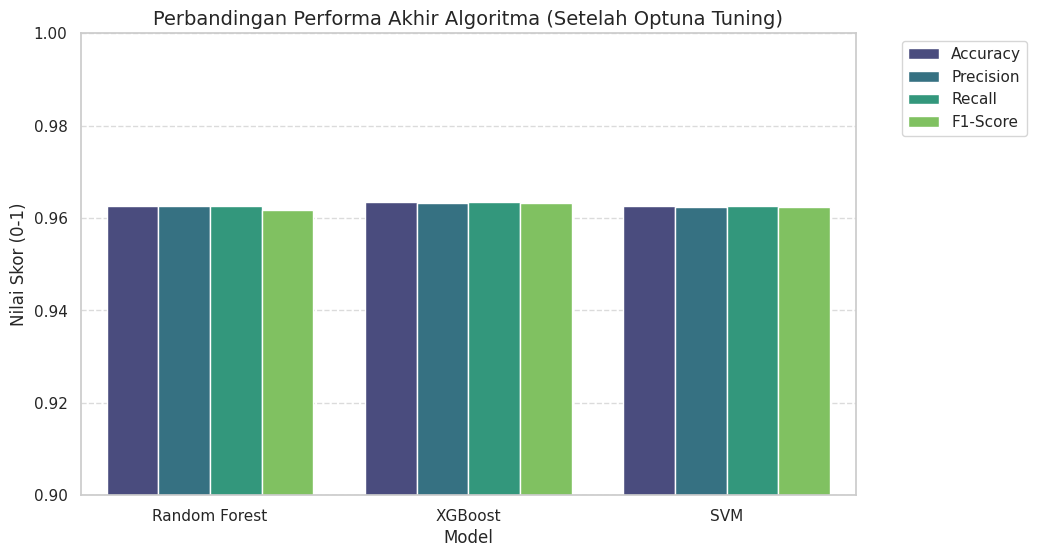

Model Random Forest mencapai F1-Score sebesar 0.9618
Model XGBoost mencapai F1-Score sebesar 0.9632
Model SVM mencapai F1-Score sebesar 0.9623


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_grid_eval.melt(id_vars='Model', var_name='Metrik', value_name='Skor')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Model', y='Skor', hue='Metrik', palette='viridis')

plt.title('Perbandingan Performa Akhir Algoritma (Setelah Optuna Tuning)', fontsize=14)
plt.ylabel('Nilai Skor (0-1)')
plt.ylim(0.90, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

for index, row in df_grid_eval.iterrows():
    print(f"Model {row['Model']} mencapai F1-Score sebesar {row['F1-Score']:.4f}")

In [66]:
y_pred_rf = grid_rf.best_estimator_.predict(X_test20)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test20)
y_pred_svm = grid_svm.best_estimator_.predict(X_test20)

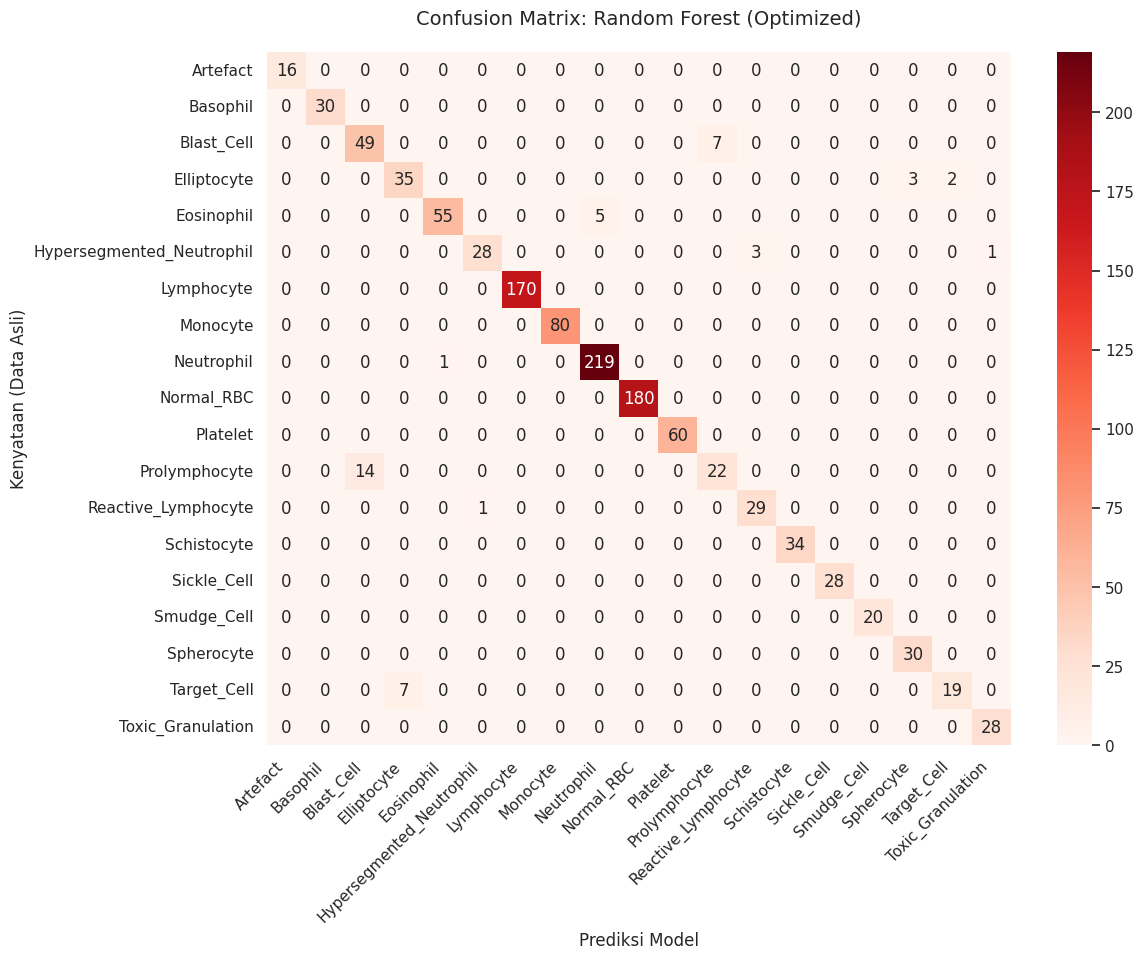

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_rf = grid_rf.best_estimator_.predict(X_test20)

plt.figure(figsize=(12, 9))
cm_rf = confusion_matrix(y_test20, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)

plt.title('Confusion Matrix: Random Forest (Optimized)', fontsize=14, pad=20)
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Data Asli)')
plt.xticks(rotation=45, ha='right')
plt.show()

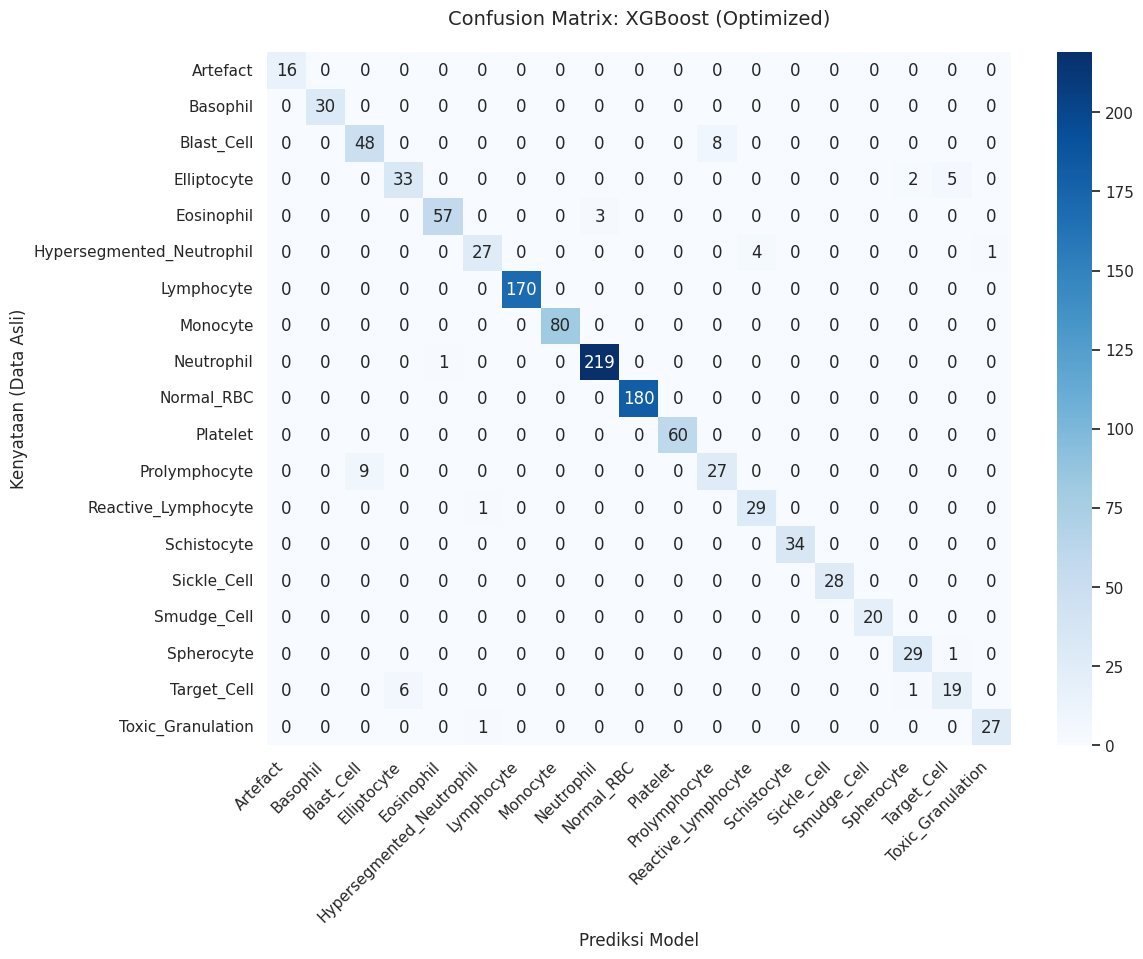

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_xgb = grid_xgb.best_estimator_.predict(X_test20)

plt.figure(figsize=(12, 9))
cm_xgb = confusion_matrix(y_test20, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)

plt.title('Confusion Matrix: XGBoost (Optimized)', fontsize=14, pad=20)
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Data Asli)')
plt.xticks(rotation=45, ha='right')
plt.show()

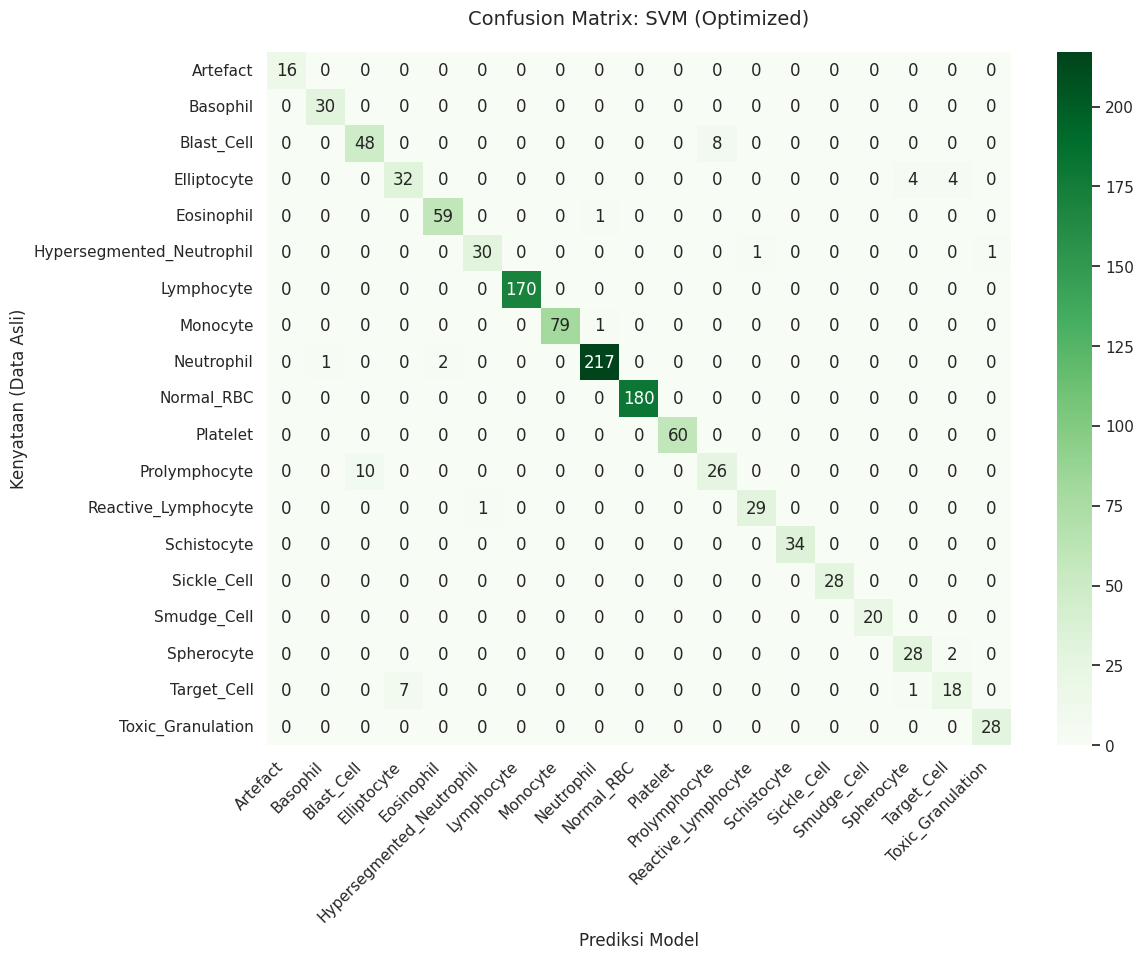

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_svm = grid_svm.best_estimator_.predict(X_test20)

plt.figure(figsize=(12, 9))
cm_svm = confusion_matrix(y_test20, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)

plt.title('Confusion Matrix: SVM (Optimized)', fontsize=14, pad=20)
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Data Asli)')
plt.xticks(rotation=45, ha='right')
plt.show()